In [ ]:
%load_ext autoreload
%autoreload 2

## Plots

In [3]:
import json
import matplotlib.pyplot as plt

In [12]:
json_objects = []
for exp_id in range(0, 6):
    fname = f"./results/1_neurons/00{520000+exp_id}.json"
    with open(fname, 'r', encoding='utf-8') as file:
        data = json.load(file)
        json_objects.append(data)

0.9785999763011932

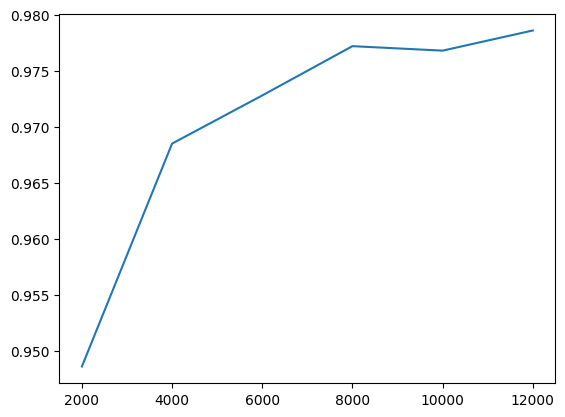

In [ ]:
accuracies = [max(js['test_acc_eval_mode']) for js in json_objects]
ks = [2000, 4000, 6000, 8000, 10000, 12000]
plt.plot(ks, accuracies)
max(accuracies)

0.9745999771356583

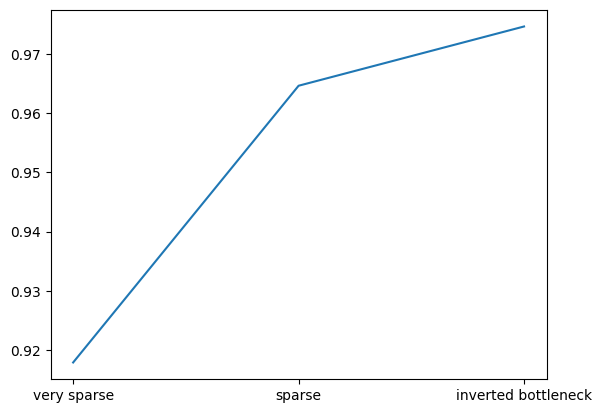

In [16]:
json_objects = []
for exp_id in range(0, 3):
    fname = f"./results/2_architectures/00{521000+exp_id}.json"
    with open(fname, 'r', encoding='utf-8') as file:
        data = json.load(file)
        json_objects.append(data)

accuracies = [max(js['test_acc_eval_mode']) for js in json_objects]
ks = ['very sparse', 'sparse', 'inverted bottleneck']
plt.plot(ks, accuracies)
max(accuracies)

## Evaluation

In [17]:
import torch
from torch import nn
from difflogic import LogicLayer, MyLogicLayer, GroupSum

l = 6
k = 8000
kwargs = {'implementation': 'python_inference', 'device': 'cpu'}
model = nn.Sequential(
    nn.Flatten(),
    MyLogicLayer(400, k, **kwargs),
    *[MyLogicLayer(k, k, **kwargs) for i in range(l-1)],
    GroupSum(k=10, tau=10.0) # debug log: this is the evilness!!!
)
model

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fb60e59d5d0>>
Traceback (most recent call last):
  File "/rds/general/user/hn621/home/anaconda3/envs/molmo/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


ModuleNotFoundError: No module named 'difflogic'

In [115]:
model.state_dict().keys()

odict_keys(['1.weights', '1.indices_stored', '2.weights', '2.indices_stored', '3.weights', '3.indices_stored', '4.weights', '4.indices_stored', '5.weights', '5.indices_stored', '6.weights', '6.indices_stored'])

In [116]:
state_dict = torch.load(f'test_model_ckpt.pth', map_location=torch.device('cpu'))
# state_dict = torch.load(f'mnist20x20_k{k}_l{l}_model_final.pth', map_location=torch.device('cpu'))
# state_dict = torch.load(f'results/1/mnist20x20_k{k}_l{l}_model.pth', map_location=torch.device('cpu'))
# indices = torch.load(f'mnist20x20_k{k}_l{l}_indices.pth')
# state_dict = torch.load(f'best_model_full.pth', map_location=torch.device('cpu'))

In [ ]:
# state_dict.keys()

odict_keys(['1.weights', '1.indices_stored', '2.weights', '2.indices_stored', '3.weights', '3.indices_stored', '4.weights', '4.indices_stored', '5.weights', '5.indices_stored', '6.weights', '6.indices_stored'])

In [118]:
# state_dict = {k.replace('indices_stacked', 'indices'):v for k, v in state_dict.items()}
# state_dict = {k.replace('indices', 'indices_stored'):v for k, v in state_dict.items()}

In [ ]:
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
from experiments import mnist_dataset
import numpy as np
import math

def eval(model, loader, mode=False):
    orig_mode = model.training
    with torch.no_grad():
        model.train(mode=mode)
        res = np.mean(
            [
                (model(x.to('cpu').round()).argmax(-1) == y.to('cpu')).to(torch.float32).mean().item()
                for x, y in loader
            ]
        )
        model.train(mode=orig_mode)
    return res.item()

train_set = mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=True)
test_set = mnist_dataset.MNIST('./data-mnist', train=False, remove_border=True)

train_set_size = math.ceil((1) * len(train_set))
valid_set_size = len(train_set) - train_set_size
train_set, validation_set = torch.utils.data.random_split(train_set, [train_set_size, valid_set_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=100, shuffle=True, pin_memory=True, drop_last=True, num_workers=4)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=100, shuffle=False, pin_memory=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, pin_memory=True, drop_last=True)

In [122]:
eval(model, test_loader)

0.9370000034570694